In [ ]:
import json
kaggle_data = {
    "username": "omnhinge",
    "key": "KGAT_781c657f85942167fc4735c1abfecedb"
}


In [ ]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print("Kaggle Connected")

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle Connected


In [ ]:
# ============================================================
# CELL 2: DOWNLOAD BOTH KAGGLE DATASETS
# ============================================================

# Dataset 1: dangerous-objects (has safe + dangerous classes)
!kaggle datasets download -d ajibsbaba/dangerousobjects \
    -p /content/raw_danger --unzip -q
print("✅ Dangerous-objects dataset downloaded")

# Dataset 2: obstacles-dataset (10 obstacle classes)
!kaggle datasets download -d idrisskh/obstacles-dataset \
    -p /content/raw_obstacle --unzip -q
print("✅ Obstacles dataset downloaded")

# Check structure
import os
print("\n--- Dangerous dataset structure ---")
for root, dirs, files_list in os.walk("/content/raw_danger"):
    level = root.replace("/content/raw_danger", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 3:
        for d in dirs:
            print(f"{indent}  {d}/")

Dataset URL: https://www.kaggle.com/datasets/ajibsbaba/dangerousobjects
License(s): Community Data License Agreement - Permissive - Version 1.0
✅ Dangerous-objects dataset downloaded
Dataset URL: https://www.kaggle.com/datasets/idrisskh/obstacles-dataset
License(s): unknown
✅ Obstacles dataset downloaded

--- Dangerous dataset structure ---
raw_danger/
  output/
  output/
    test/
    train/
    val/
    test/
      dangerous/
      safe/
      dangerous/
      safe/
    train/
      dangerous/
      safe/
      dangerous/
      safe/
    val/
      dangerous/
      safe/
      dangerous/
      safe/


In [ ]:
# ============================================================
# CELL 3: FIXED DATASET BUILDER — Based on confirmed structure


import shutil, os
from pathlib import Path

DEST = Path("/content/dataset")

# Clean any previous broken attempt
if DEST.exists():
    shutil.rmtree(DEST)
    print("🗑 Cleared old dataset folder")

# Create clean structure
for split in ["train", "validation", "test"]:
    for cls in ["safe", "obstacle", "danger"]:
        (DEST / split / cls).mkdir(parents=True, exist_ok=True)

# ── Helper ─────────────────────────────────────────────────
def copy_all(src, dst, class_name, split_name):
    """Copy all images from src to dst, renaming to avoid collisions."""
    src_path = Path(src)
    dst_path = Path(dst)
    if not src_path.exists():
        print(f"  ⚠ NOT FOUND: {src}")
        return 0
    imgs = (list(src_path.glob("*.jpg"))  +
            list(src_path.glob("*.jpeg")) +
            list(src_path.glob("*.png"))  +
            list(src_path.glob("*.JPG"))  +
            list(src_path.glob("*.PNG")))
    for i, img in enumerate(imgs):
        new_name = f"{class_name}_{split_name}_{i:05d}{img.suffix.lower()}"
        shutil.copy(img, dst_path / new_name)
    return len(imgs)

# ============================================================
# PART 1: dangerous-objects dataset
# Split mapping: train→train, val→validation, test→test
# ============================================================
DANGER_ROOT = "/content/raw_danger/output"

split_map = {
    "train": "train",
    "val":   "validation",
    "test":  "test"
}

print("📂 Copying dangerous-objects dataset...")
for src_split, dst_split in split_map.items():
    # DANGER class
    n = copy_all(
        f"{DANGER_ROOT}/{src_split}/dangerous",
        DEST / dst_split / "danger",
        "danger", dst_split
    )
    print(f"  ✅ danger  → {dst_split}: {n} images")

    # SAFE class
    n = copy_all(
        f"{DANGER_ROOT}/{src_split}/safe",
        DEST / dst_split / "safe",
        "safe", dst_split
    )
    print(f"  ✅ safe    → {dst_split}: {n} images")

# ============================================================
# PART 2: obstacles dataset
# All 10 sub-classes merged into single "obstacle" class
# Has train/ and test/ only → we split test into val+test
# ============================================================
OBSTACLE_ROOT = "/content/raw_obstacle/obstacles dataset"

OBSTACLE_SUBCLASSES = [
    "chair", "door", "fence", "garbage_bin", "obstacle",
    "plant", "pothole", "stairs", "table", "vehicle"
]

print("\n📂 Copying obstacles dataset...")

# Collect all train images across all 10 subclasses
train_obs_imgs = []
for sub in OBSTACLE_SUBCLASSES:
    src = Path(f"{OBSTACLE_ROOT}/train/{sub}")
    if src.exists():
        imgs = (list(src.glob("*.jpg"))  +
                list(src.glob("*.jpeg")) +
                list(src.glob("*.png"))  +
                list(src.glob("*.JPG"))  +
                list(src.glob("*.PNG")))
        train_obs_imgs.extend(imgs)
print(f"  Found {len(train_obs_imgs)} obstacle train images")

# Collect all test images
test_obs_imgs = []
for sub in OBSTACLE_SUBCLASSES:
    src = Path(f"{OBSTACLE_ROOT}/test/{sub}")
    if src.exists():
        imgs = (list(src.glob("*.jpg"))  +
                list(src.glob("*.jpeg")) +
                list(src.glob("*.png"))  +
                list(src.glob("*.JPG"))  +
                list(src.glob("*.PNG")))
        test_obs_imgs.extend(imgs)
print(f"  Found {len(test_obs_imgs)} obstacle test images")

# Copy train obstacles
for i, img in enumerate(train_obs_imgs):
    new_name = f"obstacle_train_{i:05d}{img.suffix.lower()}"
    shutil.copy(img, DEST / "train" / "obstacle" / new_name)
print(f"  ✅ obstacle → train: {len(train_obs_imgs)} images")

# Split test → 50% validation, 50% test
import random
random.seed(42)
random.shuffle(test_obs_imgs)
half = len(test_obs_imgs) // 2
val_obs  = test_obs_imgs[:half]
test_obs = test_obs_imgs[half:]

for i, img in enumerate(val_obs):
    new_name = f"obstacle_val_{i:05d}{img.suffix.lower()}"
    shutil.copy(img, DEST / "validation" / "obstacle" / new_name)
print(f"  ✅ obstacle → validation: {len(val_obs)} images")

for i, img in enumerate(test_obs):
    new_name = f"obstacle_test_{i:05d}{img.suffix.lower()}"
    shutil.copy(img, DEST / "test" / "obstacle" / new_name)
print(f"  ✅ obstacle → test: {len(test_obs)} images")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n========== FINAL DATASET SUMMARY ==========")
total = 0
for split in ["train", "validation", "test"]:
    print(f"\n  {split}/")
    for cls in ["safe", "obstacle", "danger"]:
        count = len(list((DEST / split / cls).glob("*")))
        bar   = "█" * (count // 40)
        print(f"    {cls:10s}: {count:5d} images  {bar}")
        total += count
print(f"\n  TOTAL: {total} images across all splits")

📂 Copying dangerous-objects dataset...
  ✅ danger  → train: 800 images
  ✅ safe    → train: 179 images
  ✅ danger  → validation: 100 images
  ✅ safe    → validation: 22 images
  ✅ danger  → test: 100 images
  ✅ safe    → test: 23 images

📂 Copying obstacles dataset...
  Found 3132 obstacle train images
  Found 432 obstacle test images
  ✅ obstacle → train: 3132 images
  ✅ obstacle → validation: 216 images
  ✅ obstacle → test: 216 images

========== FINAL DATASET SUMMARY ==========

  train/
    safe      :   179 images  ████
    obstacle  :  3132 images  ██████████████████████████████████████████████████████████████████████████████
    danger    :   800 images  ████████████████████

  validation/
    safe      :    22 images  
    obstacle  :   216 images  █████
    danger    :   100 images  ██

  test/
    safe      :    23 images  
    obstacle  :   216 images  █████
    danger    :   100 images  ██

  TOTAL: 4788 images across all splits


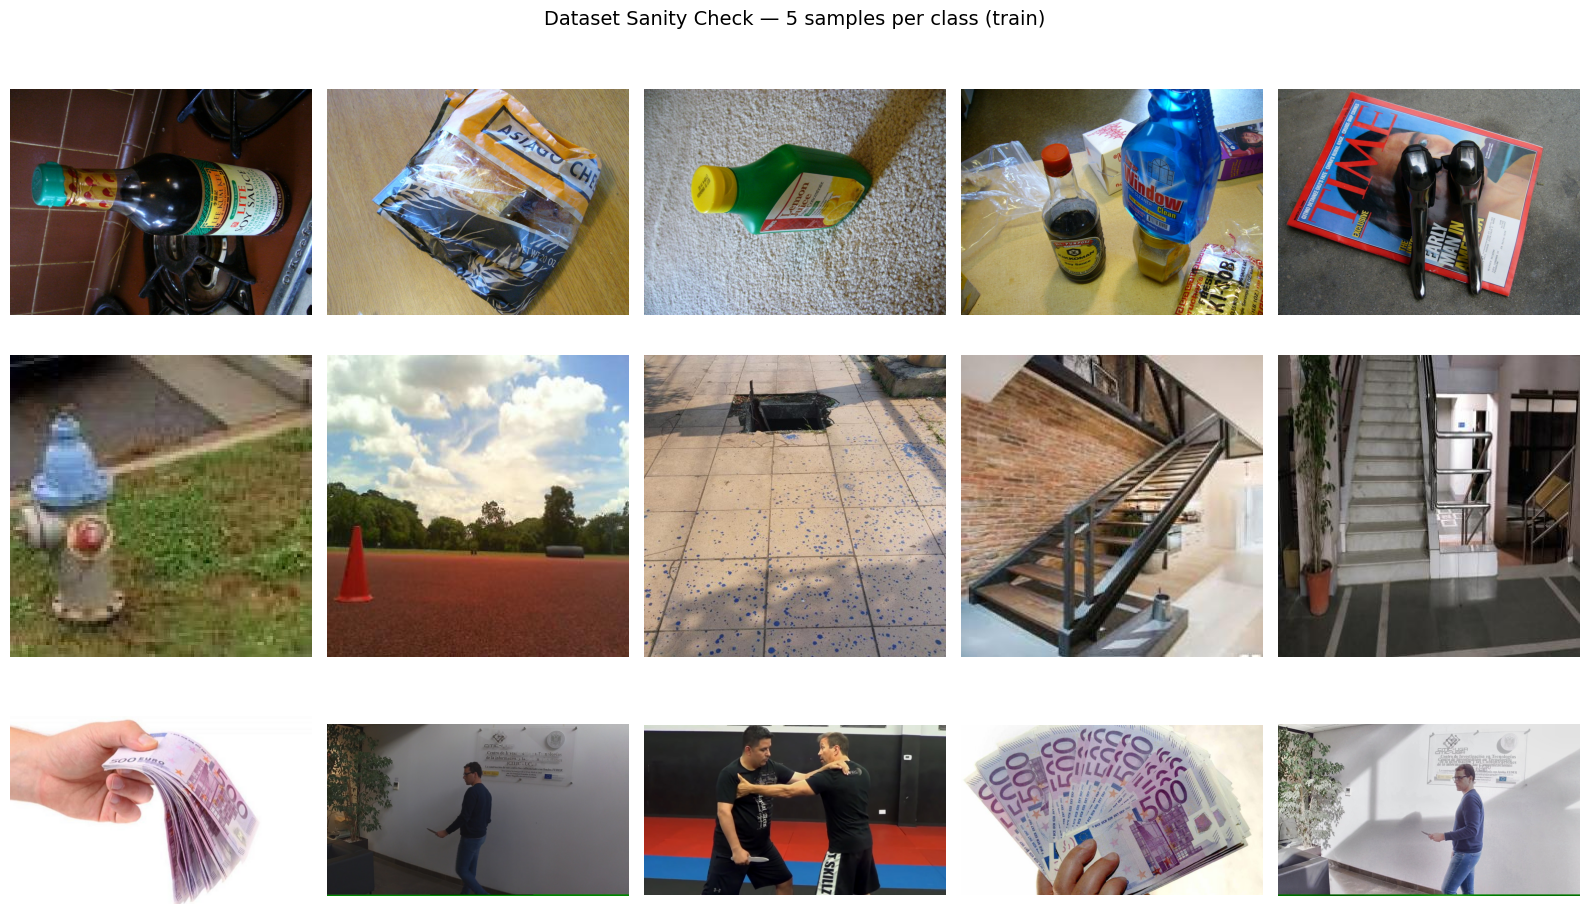

✅ If you see images in all 3 rows — dataset is correct!


In [ ]:
# ============================================================
# CELL 3d: VISUAL SANITY CHECK
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
from pathlib import Path

DEST        = Path("/content/dataset")
CLASS_NAMES = ["safe", "obstacle", "danger"]
COLORS      = {"safe": "#4CAF50", "obstacle": "#FF9800", "danger": "#F44336"}

fig, axes = plt.subplots(3, 5, figsize=(16, 10))
fig.suptitle("Dataset Sanity Check — 5 samples per class (train)",
             fontsize=14)

for row, cls in enumerate(CLASS_NAMES):
    imgs = list((DEST / "train" / cls).glob("*"))
    samples = random.sample(imgs, min(5, len(imgs)))
    for col in range(5):
        ax = axes[row][col]
        if col < len(samples):
            try:
                img = mpimg.imread(samples[col])
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "Error", ha="center", va="center")
        ax.axis("off")
        if col == 0:
            ax.set_ylabel(cls.upper(), fontsize=13,
                          color=COLORS[cls], fontweight="bold")

plt.tight_layout()
plt.savefig("/content/dataset_sanity_check.png", dpi=150)
plt.show()
print("✅ If you see images in all 3 rows — dataset is correct!")

Found 4111 files belonging to 3 classes.
Found 338 files belonging to 3 classes.
Found 339 files belonging to 3 classes.
✅ Datasets loaded
   Train batches     : 129
   Validation batches: 11
   Test batches      : 11


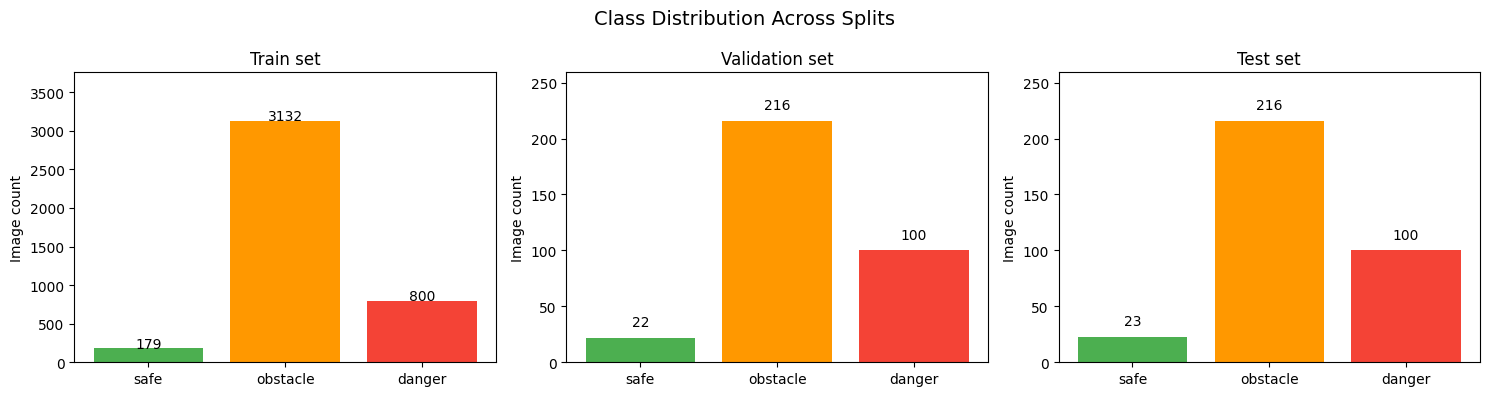


⚖ Class weights (to handle imbalance):
   safe      : 7.6555
   obstacle  : 0.4375
   danger    : 1.7129

✅ Preprocessing pipelines ready


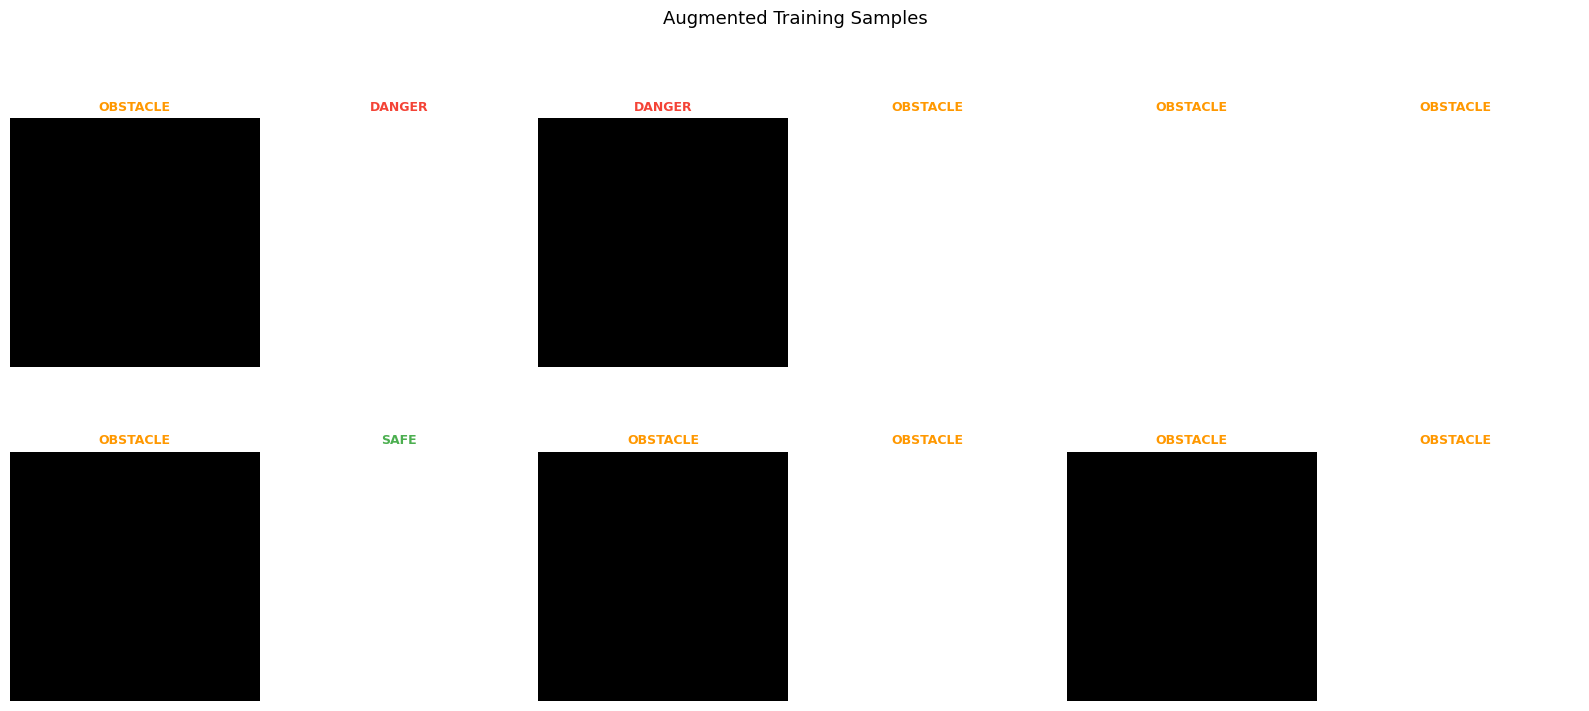

✅ Cell 4 complete


In [ ]:
# ============================================================
# CELL 4: DATA PREPROCESSING & AUGMENTATION
# ============================================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3
CLASS_NAMES = ["safe", "obstacle", "danger"]

# ── Load raw datasets ──────────────────────────────────────
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASS_NAMES,
    shuffle=True,
    seed=42
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASS_NAMES,
    shuffle=False
)
test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    "/content/dataset/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    class_names=CLASS_NAMES,
    shuffle=False
)

print("✅ Datasets loaded")
print(f"   Train batches     : {len(train_ds_raw)}")
print(f"   Validation batches: {len(val_ds_raw)}")
print(f"   Test batches      : {len(test_ds_raw)}")

# ── Count class distribution ───────────────────────────────
from pathlib import Path
import matplotlib.patches as mpatches

DEST = Path("/content/dataset")
split_counts = {}
for split in ["train", "validation", "test"]:
    split_counts[split] = {}
    for cls in CLASS_NAMES:
        split_counts[split][cls] = len(list((DEST/split/cls).glob("*")))

# Plot distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ["#4CAF50", "#FF9800", "#F44336"]
for i, split in enumerate(["train", "validation", "test"]):
    counts = [split_counts[split][c] for c in CLASS_NAMES]
    bars = axes[i].bar(CLASS_NAMES, counts, color=colors)
    axes[i].set_title(f"{split.capitalize()} set", fontsize=12)
    axes[i].set_ylabel("Image count")
    axes[i].set_ylim(0, max(counts) * 1.2)
    for bar, val in zip(bars, counts):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 10,
                     str(val), ha="center", fontsize=10)
plt.suptitle("Class Distribution Across Splits", fontsize=14)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()

# ── Compute class weights (handles imbalance) ──────────────
total_train = sum(split_counts["train"].values())
class_weights = {}
for i, cls in enumerate(CLASS_NAMES):
    n = split_counts["train"][cls]
    # Formula: total / (num_classes * class_count)
    class_weights[i] = total_train / (NUM_CLASSES * n) if n > 0 else 1.0
print("\n⚖ Class weights (to handle imbalance):")
for i, cls in enumerate(CLASS_NAMES):
    print(f"   {cls:10s}: {class_weights[i]:.4f}")

# ── Normalization ──────────────────────────────────────────
normalization = tf.keras.layers.Rescaling(1./255)

# ── Augmentation (applied only on train) ──────────────────
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomBrightness(0.1),
], name="augmentation")

def preprocess_train(images, labels):
    images = normalization(images)
    images = augmentation(images, training=True)
    return images, labels

def preprocess_eval(images, labels):
    images = normalization(images)
    return images, labels

# ── Build optimized pipelines ──────────────────────────────
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.map(
    preprocess_train, num_parallel_calls=AUTOTUNE
).cache().shuffle(500).prefetch(AUTOTUNE)

val_ds = val_ds_raw.map(
    preprocess_eval, num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

test_ds = test_ds_raw.map(
    preprocess_eval, num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

print("\n✅ Preprocessing pipelines ready")

# ── Visualize sample images with augmentation ──────────────
plt.figure(figsize=(16, 8))
class_colors = {"safe": "#4CAF50", "obstacle": "#FF9800", "danger": "#F44336"}

for images, labels in train_ds_raw.take(1):
    for i in range(12):
        ax = plt.subplot(2, 6, i + 1)
        # Show augmented version
        img_norm  = normalization(tf.expand_dims(images[i], 0))
        img_aug   = augmentation(img_norm, training=True)[0].numpy()
        img_aug   = np.clip(img_aug, 0, 1)
        plt.imshow(img_aug)
        cls_name  = CLASS_NAMES[np.argmax(labels[i])]
        plt.title(cls_name.upper(), fontsize=9,
                  color=class_colors[cls_name], fontweight="bold")
        plt.axis("off")

plt.suptitle("Augmented Training Samples", fontsize=13)
plt.tight_layout()
plt.savefig("/content/augmented_samples.png", dpi=150)
plt.show()
print("✅ Cell 4 complete")

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 56, 56, 128)    │             

 Total params: 784,675 (2.99 MB)

 Trainable params: 782,243 (2.98 MB)

 Non-trainable params: 2,432 (9.50 KB)


🚀 Training CNN from scratch...
Epoch 1/40
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.2188 - loss: 1.6992

129/129 ━━━━━━━━━━━━━━━━━━━━ 121s 307ms/step - accuracy: 0.2508 - loss: 1.5908 - val_accuracy: 0.6391 - val_loss: 0.9452 - learning_rate: 1.0000e-04
Epoch 2/40
129/129 ━━━━━━━━━━━━━━━━━━━━ 20s 153ms/step - accuracy: 0.2795 - loss: 1.5545 - val_accuracy: 0.6391 - val_loss: 0.9710 - learning_rate: 1.0000e-04
Epoch 3/40
129/129 ━━━━━━━━━━━━━━━━━━━━ 20s 159ms/step - accuracy: 0.2810 - loss: 1.4555 - val_accuracy: 0.6391 - val_loss: 1.0141 - learning_rate: 1.0000e-04
Epoch 4/40
129/129 ━━━━━━━━━━━━━━━━━━━━ 22s 168ms/step - accuracy: 0.2858 - loss: 1.4303 - val_accuracy: 0.3550 - val_loss: 1.0984 - learning_rate: 1.0000e-04
Epoch 5/40
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3160 - loss: 1.3730
Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 175ms/step - accuracy: 0.3150 - loss: 1.3972 - val_accuracy: 0.6391 - val_loss: 0.9939 - learning_rate: 1.0000e-04
Epoch 6/40
129/129 ━━━━━━━━━━━━━━━━━━━━ 22s 167ms/step - accu

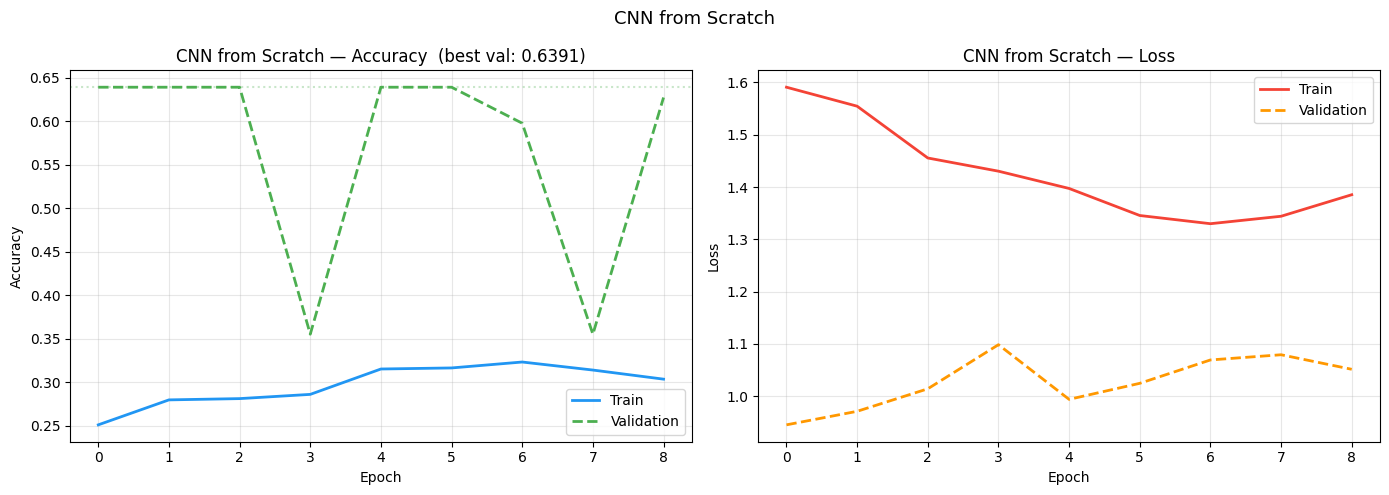

   Saved: /content/cnn_curves.png

📊 CNN Test Accuracy : 0.6372
   CNN Test Loss     : 0.9467
✅ Cell 5 complete


In [ ]:
# ============================================================
# CELL 5: CUSTOM CNN FROM SCRATCH
# ============================================================
from tensorflow.keras import layers, models

def build_cnn(input_shape=(224, 224, 3), num_classes=3):
    """
    Custom CNN — 4 conv blocks with batch norm + dropout,
    followed by a dense classifier head.
    """
    model = models.Sequential(name="CustomCNN")

    # ── Block 1: 32 filters ───────────────────────────────
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(32, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # ── Block 2: 64 filters ───────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(64, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.25))

    # ── Block 3: 128 filters ──────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.Conv2D(128, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.3))

    # ── Block 4: 256 filters ──────────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation("relu"))
    model.add(layers.MaxPooling2D(2, 2))
    model.add(layers.Dropout(0.3))

    # ── Classifier head ───────────────────────────────────
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(512, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(num_classes, activation="softmax"))

    return model

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

# ── Callbacks ──────────────────────────────────────────────
cnn_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "/content/cnn_best.h5",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=0
    )
]

# ── Train ──────────────────────────────────────────────────
print("\n🚀 Training CNN from scratch...")
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=cnn_callbacks,
    class_weight=class_weights,
    verbose=1
)

# ── Plot training curves ───────────────────────────────────
def plot_history(history, title, save_path):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    ax1.plot(history.history["accuracy"],
             label="Train", color="#2196F3", linewidth=2)
    ax1.plot(history.history["val_accuracy"],
             label="Validation", color="#4CAF50",
             linewidth=2, linestyle="--")
    best_val = max(history.history["val_accuracy"])
    ax1.axhline(best_val, color="#4CAF50", alpha=0.3, linestyle=":")
    ax1.set_title(f"{title} — Accuracy  (best val: {best_val:.4f})")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(history.history["loss"],
             label="Train", color="#F44336", linewidth=2)
    ax2.plot(history.history["val_loss"],
             label="Validation", color="#FF9800",
             linewidth=2, linestyle="--")
    ax2.set_title(f"{title} — Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"   Saved: {save_path}")

plot_history(cnn_history, "CNN from Scratch",
             "/content/cnn_curves.png")

# Quick eval on test set
cnn_loss, cnn_acc = cnn_model.evaluate(test_ds, verbose=0)
print(f"\n📊 CNN Test Accuracy : {cnn_acc:.4f}")
print(f"   CNN Test Loss     : {cnn_loss:.4f}")
print("✅ Cell 5 complete")

In [ ]:
# ============================================================
# CELL 6: HYPERPARAMETER EXPERIMENTS
# ============================================================
import pandas as pd

experiment_results = []

# Configs to test
configs = [
    {"epochs": 10, "batch": 32, "opt": "Adam",    "lr": 1e-4},
    {"epochs": 20, "batch": 32, "opt": "Adam",    "lr": 1e-4},
    {"epochs": 30, "batch": 32, "opt": "Adam",    "lr": 1e-4},
    {"epochs": 20, "batch": 64, "opt": "Adam",    "lr": 1e-4},
    {"epochs": 20, "batch": 32, "opt": "RMSprop", "lr": 1e-4},
    {"epochs": 20, "batch": 32, "opt": "Adam",    "lr": 1e-3},
]

for cfg in configs:
    label = f"E{cfg['epochs']}_B{cfg['batch']}_{cfg['opt']}_lr{cfg['lr']}"
    print(f"\n▶ {label}")

    # Rebuild datasets with this config's batch size
    tr = tf.keras.utils.image_dataset_from_directory(
        "/content/dataset/train",
        image_size=IMG_SIZE, batch_size=cfg["batch"],
        label_mode="categorical", class_names=CLASS_NAMES,
        shuffle=True, seed=42
    ).map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    vl = tf.keras.utils.image_dataset_from_directory(
        "/content/dataset/validation",
        image_size=IMG_SIZE, batch_size=cfg["batch"],
        label_mode="categorical", class_names=CLASS_NAMES,
        shuffle=False
    ).map(preprocess_eval, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

    # Build fresh model
    m = build_cnn()
    opt = (tf.keras.optimizers.Adam(cfg["lr"])
           if cfg["opt"] == "Adam"
           else tf.keras.optimizers.RMSprop(cfg["lr"]))
    m.compile(optimizer=opt,
              loss="categorical_crossentropy",
              metrics=["accuracy"])

    cb = [tf.keras.callbacks.EarlyStopping(
        patience=6, restore_best_weights=True,
        monitor="val_accuracy")]

    hist = m.fit(
        tr, validation_data=vl,
        epochs=cfg["epochs"],
        callbacks=cb,
        class_weight=class_weights,
        verbose=0
    )

    best_acc  = max(hist.history["val_accuracy"])
    best_loss = min(hist.history["val_loss"])
    ran       = len(hist.history["accuracy"])

    experiment_results.append({
        "Config":      label,
        "Optimizer":   cfg["opt"],
        "Epochs req.": cfg["epochs"],
        "Ran epochs":  ran,
        "Batch":       cfg["batch"],
        "LR":          cfg["lr"],
        "Val Acc":     round(best_acc,  4),
        "Val Loss":    round(best_loss, 4),
    })
    print(f"   ✅ Val Acc: {best_acc:.4f}  (ran {ran} epochs)")

exp_df = pd.DataFrame(experiment_results)
print("\n========= HYPERPARAMETER RESULTS =========")
print(exp_df[["Config","Val Acc","Val Loss","Ran epochs"]].to_string(index=False))

best_cfg = exp_df.loc[exp_df["Val Acc"].idxmax(), "Config"]
print(f"\n🏆 Best config: {best_cfg}")

# ── Plot ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
short_labels = [r["Config"].replace("_", "\n") for r in experiment_results]
accs  = [r["Val Acc"]  for r in experiment_results]
losses= [r["Val Loss"] for r in experiment_results]

bar_colors = ["#4CAF50" if a == max(accs) else "#2196F3" for a in accs]
bars1 = ax1.bar(range(len(accs)), accs, color=bar_colors)
ax1.set_xticks(range(len(accs)))
ax1.set_xticklabels(short_labels, fontsize=7)
ax1.set_title("Validation Accuracy by Config")
ax1.set_ylabel("Val Accuracy"); ax1.set_ylim(0, 1.1)
ax1.grid(axis="y", alpha=0.3)
for bar, val in zip(bars1, accs):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=8)

bars2 = ax2.bar(range(len(losses)), losses, color="#FF9800")
ax2.set_xticks(range(len(losses)))
ax2.set_xticklabels(short_labels, fontsize=7)
ax2.set_title("Validation Loss by Config")
ax2.set_ylabel("Val Loss")
ax2.grid(axis="y", alpha=0.3)
for bar, val in zip(bars2, losses):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{val:.3f}", ha="center", fontsize=8)

plt.suptitle("Hyperparameter Experiment Comparison", fontsize=13)
plt.tight_layout()
plt.savefig("/content/hyperparameter_comparison.png", dpi=150)
plt.show()
print("✅ Cell 6 complete")


▶ E10_B32_Adam_lr0.0001
Found 4111 files belonging to 3 classes.
Found 338 files belonging to 3 classes.



🚀 Training MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

  Phase 1: Training classification head...
Epoch 1/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.3946 - loss: 1.4887

129/129 ━━━━━━━━━━━━━━━━━━━━ 52s 259ms/step - accuracy: 0.3960 - loss: 1.4030 - val_accuracy: 0.5503 - val_loss: 0.8338 - learning_rate: 1.0000e-04
Epoch 2/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4171 - loss: 1.2294

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4094 - loss: 1.2135 - val_accuracy: 0.6331 - val_loss: 0.7794 - learning_rate: 1.0000e-04
Epoch 3/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4159 - loss: 1.2057

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - accuracy: 0.4303 - loss: 1.1906 - val_accuracy: 0.6450 - val_loss: 0.7647 - learning_rate: 1.0000e-04
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4347 - loss: 1.1091 - val_accuracy: 0.6420 - val_loss: 0.8752 - learning_rate: 1.0000e-04
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4425 - loss: 1.0753 - val_accuracy: 0.6361 - val_loss: 1.1108 - learning_rate: 1.0000e-04
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4474 - loss: 1.1435
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4505 - loss: 1.0597 - val_accuracy: 0.6450 - val_loss: 1.0524 - learning_rate: 1.0000e-04
Epoch 7/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4789 - loss: 1.0227

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.4719 - loss: 1.0077 - val_accuracy: 0.6746 - val_loss: 0.9672 - learning_rate: 3.0000e-05
Epoch 8/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4730 - loss: 1.0189

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4712 - loss: 1.0047 - val_accuracy: 0.7041 - val_loss: 0.8659 - learning_rate: 3.0000e-05
Epoch 9/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4587 - loss: 0.9772
Epoch 9: ReduceLROnPlateau reducing learning rate to 8.999999772640877e-06.
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4544 - loss: 0.9837 - val_accuracy: 0.6923 - val_loss: 0.9143 - learning_rate: 3.0000e-05
Epoch 10/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4619 - loss: 0.9460 - val_accuracy: 0.7012 - val_loss: 0.9062 - learning_rate: 9.0000e-06
Epoch 11/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4647 - loss: 0.9219

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4753 - loss: 0.9329 - val_accuracy: 0.7101 - val_loss: 0.8804 - learning_rate: 9.0000e-06
Epoch 12/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4534 - loss: 0.9571
Epoch 12: ReduceLROnPlateau reducing learning rate to 2.6999998226528985e-06.


129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.4658 - loss: 0.9527 - val_accuracy: 0.7130 - val_loss: 0.8731 - learning_rate: 9.0000e-06
Epoch 13/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4578 - loss: 0.9559 - val_accuracy: 0.7101 - val_loss: 0.8598 - learning_rate: 2.7000e-06
Epoch 14/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4651 - loss: 0.9514 - val_accuracy: 0.7101 - val_loss: 0.8683 - learning_rate: 2.7000e-06
Epoch 15/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4677 - loss: 0.9701
Epoch 15: ReduceLROnPlateau reducing learning rate to 8.099999604382901e-07.
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4756 - loss: 0.9565 - val_accuracy: 0.7130 - val_loss: 0.8684 - learning_rate: 2.7000e-06
Epoch 16/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.4785 - loss: 0.9321 - val_accuracy: 0.7130 - val_loss: 0.8431 - learning_rate: 8.1000e-07
Epoch 17/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.4782 - loss: 0.9239 - val_accuracy: 0.7160 - val_loss: 0.8582 - learning_rate: 8.1000e-07
Epoch 18/20
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4730 - loss: 0.9931
Epoch 18: ReduceLROnPlateau reducing learning rate to 2.4299998813148704e-07.
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4697 - loss: 0.9652 - val_accuracy: 0.7130 - val_loss: 0.8710 - learning_rate: 8.1000e-07
Epoch 19/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.4663 - loss: 0.9466 - val_accuracy: 0.7101 - val_loss: 0.8617 - learning_rate: 2.4300e-07
Epoch 20/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.4751 - loss: 0.9361 - val_accuracy: 0.7101 - val_loss: 0.8527 - learning_rate: 2.4300e-07
Restoring model weights from the end of the best epoch: 17.

  Phase 2: Fine-tuning top 20 layers of MobileNetV2...
Epoch 1/15
128/129 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.3975 - loss: 1.5162

129/129 ━━━━━━━━━━━━━━━━━━━━ 37s 168ms/step - accuracy: 0.4096 - loss: 1.3799 - val_accuracy: 0.6953 - val_loss: 0.8060
Epoch 2/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4310 - loss: 1.1619 - val_accuracy: 0.6361 - val_loss: 0.9116
Epoch 3/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4320 - loss: 1.0995 - val_accuracy: 0.6124 - val_loss: 0.9737
Epoch 4/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.4340 - loss: 1.0887 - val_accuracy: 0.6272 - val_loss: 1.0142
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4471 - loss: 1.0154 - val_accuracy: 0.6361 - val_loss: 1.0344
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.4690 - loss: 0.9461 - val_accuracy: 0.6361 - val_loss: 1.0376
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.4649 - loss: 0.9451 - val_accuracy: 0.6391 - val_loss: 1.0324
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 1.


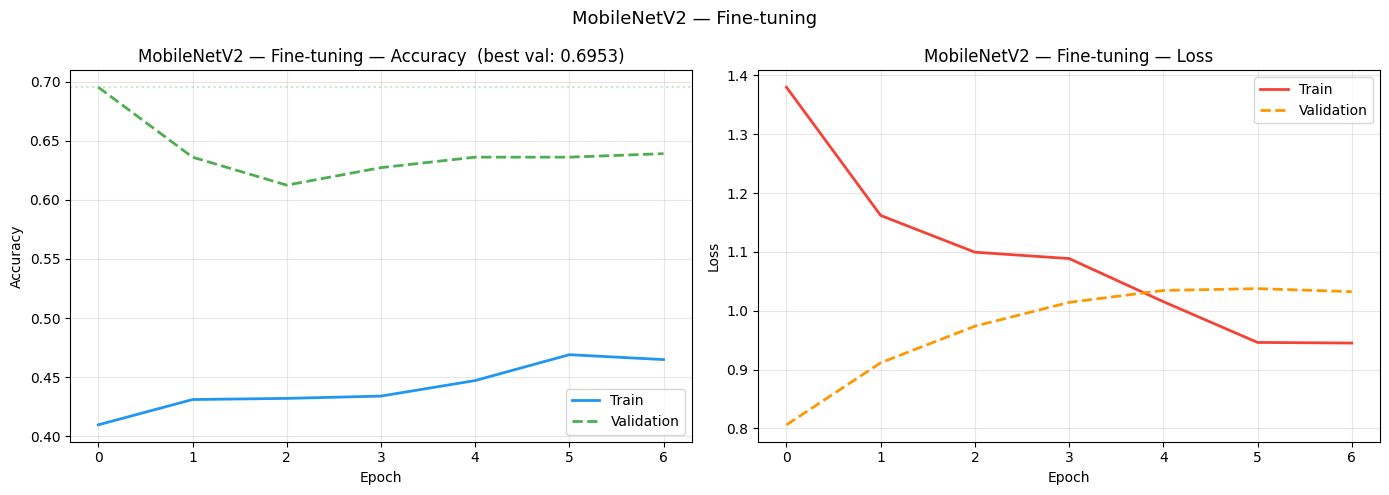

   Saved: /content/mobilenetv2_curves.png

  ✅ MobileNetV2 Test Acc: 0.6932

🚀 Training ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step

  Phase 1: Training classification head...
Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2672 - loss: 1.3335

129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 209ms/step - accuracy: 0.2802 - loss: 1.3079 - val_accuracy: 0.4260 - val_loss: 1.0529 - learning_rate: 1.0000e-04
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3121 - loss: 1.3018

129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.3172 - loss: 1.2618 - val_accuracy: 0.6331 - val_loss: 0.9869 - learning_rate: 1.0000e-04
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3767 - loss: 1.1097

129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.3797 - loss: 1.1621 - val_accuracy: 0.6923 - val_loss: 0.9064 - learning_rate: 1.0000e-04
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.3982 - loss: 1.1442 - val_accuracy: 0.3787 - val_loss: 1.0942 - learning_rate: 1.0000e-04
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 89ms/step - accuracy: 0.3975 - loss: 1.1143 - val_accuracy: 0.5178 - val_loss: 0.9326 - learning_rate: 1.0000e-04
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.3873 - loss: 1.0661

129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 94ms/step - accuracy: 0.3989 - loss: 1.0645 - val_accuracy: 0.7515 - val_loss: 0.6464 - learning_rate: 1.0000e-04
Epoch 7/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.4091 - loss: 1.0963 - val_accuracy: 0.5799 - val_loss: 0.9719 - learning_rate: 1.0000e-04
Epoch 8/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.4235 - loss: 1.0270 - val_accuracy: 0.4911 - val_loss: 0.8804 - learning_rate: 1.0000e-04
Epoch 9/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.4282 - loss: 1.0071
Epoch 9: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.4274 - loss: 1.0268 - val_accuracy: 0.7041 - val_loss: 0.6917 - learning_rate: 1.0000e-04
Epoch 10/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 0.4374 - loss: 1.0036 - val_accuracy: 0.7485 - val_loss: 0.6737 - learning_rate: 3.0000e-05
Epoch 11/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - accuracy: 

...

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.3838 - loss: 1.0641 - val_accuracy: 0.5976 - val_loss: 0.8808
Epoch 5/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.4155 - loss: 0.9978 - val_accuracy: 0.5917 - val_loss: 0.8663
Epoch 6/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.3993 - loss: 1.0163

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 118ms/step - accuracy: 0.4077 - loss: 0.9860 - val_accuracy: 0.7308 - val_loss: 0.7246
Epoch 7/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.4228 - loss: 0.9233

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 116ms/step - accuracy: 0.4451 - loss: 0.9383 - val_accuracy: 0.7426 - val_loss: 0.6621
Epoch 8/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.4456 - loss: 0.9176 - val_accuracy: 0.6775 - val_loss: 0.8071
Epoch 9/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.4680 - loss: 0.8514 - val_accuracy: 0.6805 - val_loss: 0.7524
Epoch 10/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.4777 - loss: 0.8285 - val_accuracy: 0.7130 - val_loss: 0.7041
Epoch 11/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.5280 - loss: 0.7670

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 119ms/step - accuracy: 0.5103 - loss: 0.7890 - val_accuracy: 0.7722 - val_loss: 0.6084
Epoch 12/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.4996 - loss: 0.8334 - val_accuracy: 0.6716 - val_loss: 0.7353
Epoch 13/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.4865 - loss: 0.7852

129/129 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.5016 - loss: 0.7492 - val_accuracy: 0.7811 - val_loss: 0.6056
Epoch 14/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 110ms/step - accuracy: 0.4967 - loss: 0.7555 - val_accuracy: 0.7751 - val_loss: 0.6189
Epoch 15/15
129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 111ms/step - accuracy: 0.4943 - loss: 0.7748 - val_accuracy: 0.7544 - val_loss: 0.6622
Restoring model weights from the end of the best epoch: 13.


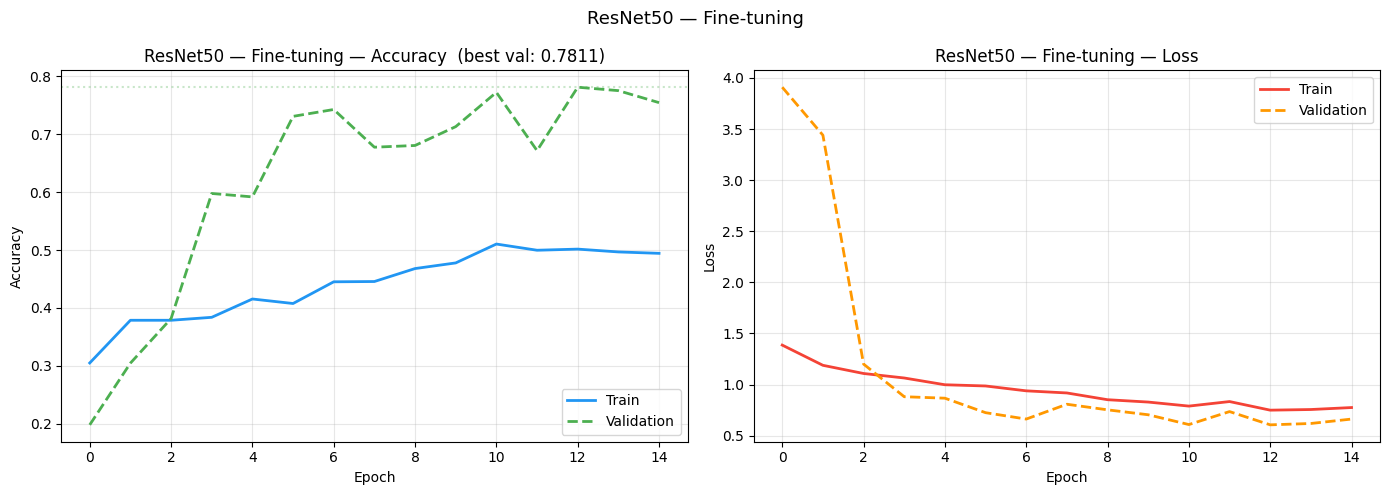

   Saved: /content/resnet50_curves.png

  ✅ ResNet50 Test Acc: 0.7286

🚀 Training VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step

  Phase 1: Training classification head...
Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.4755 - loss: 1.3918

129/129 ━━━━━━━━━━━━━━━━━━━━ 59s 329ms/step - accuracy: 0.4456 - loss: 1.3082 - val_accuracy: 0.3402 - val_loss: 1.0474 - learning_rate: 1.0000e-04
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.4520 - loss: 1.1728

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.4544 - loss: 1.1065 - val_accuracy: 0.4527 - val_loss: 0.9962 - learning_rate: 1.0000e-04
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.4542 - loss: 1.0652

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.4510 - loss: 1.0287 - val_accuracy: 0.6420 - val_loss: 0.8180 - learning_rate: 1.0000e-04
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.5036 - loss: 0.9510

129/129 ━━━━━━━━━━━━━━━━━━━━ 24s 183ms/step - accuracy: 0.4948 - loss: 0.9794 - val_accuracy: 0.6834 - val_loss: 0.7137 - learning_rate: 1.0000e-04
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.4743 - loss: 0.9645

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.4836 - loss: 0.9498 - val_accuracy: 0.8047 - val_loss: 0.5553 - learning_rate: 1.0000e-04
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.5108 - loss: 0.9221 - val_accuracy: 0.7337 - val_loss: 0.6169 - learning_rate: 1.0000e-04
Epoch 7/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5171 - loss: 0.8647

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.5060 - loss: 0.8918 - val_accuracy: 0.8402 - val_loss: 0.4354 - learning_rate: 1.0000e-04
Epoch 8/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.4982 - loss: 0.8826 - val_accuracy: 0.8314 - val_loss: 0.4511 - learning_rate: 1.0000e-04
Epoch 9/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.5084 - loss: 0.8458 - val_accuracy: 0.8284 - val_loss: 0.4605 - learning_rate: 1.0000e-04
Epoch 10/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.5164 - loss: 0.8404 - val_accuracy: 0.8225 - val_loss: 0.4306 - learning_rate: 1.0000e-04
Epoch 11/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.5235 - loss: 0.8134 - val_accuracy: 0.8314 - val_loss: 0.4531 - learning_rate: 1.0000e-04
Epoch 12/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5455 - loss: 0.8134

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.5351 - loss: 0.8234 - val_accuracy: 0.8698 - val_loss: 0.3492 - learning_rate: 1.0000e-04
Epoch 13/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5245 - loss: 0.8095

129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 182ms/step - accuracy: 0.5274 - loss: 0.8022 - val_accuracy: 0.8994 - val_loss: 0.3193 - learning_rate: 1.0000e-04
Epoch 14/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.5459 - loss: 0.7885 - val_accuracy: 0.8876 - val_loss: 0.3237 - learning_rate: 1.0000e-04
Epoch 15/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 180ms/step - accuracy: 0.5240 - loss: 0.7996 - val_accuracy: 0.8669 - val_loss: 0.3384 - learning_rate: 1.0000e-04
Epoch 16/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.5255 - loss: 0.7833
Epoch 16: ReduceLROnPlateau reducing learning rate to 2.9999999242136255e-05.
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.5308 - loss: 0.7887 - val_accuracy: 0.8757 - val_loss: 0.3214 - learning_rate: 1.0000e-04
Epoch 17/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 23s 181ms/step - accuracy: 0.5473 - loss: 0.7401 - val_accuracy: 0.8787 - val_loss: 0.3244 - learning_rate: 3.0000e-05
Epoch 18/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 41s 180ms/step -

In [ ]:
# ============================================================
# CELL 7: TRANSFER LEARNING — VGG16, ResNet50, MobileNetV2
# ============================================================
from tensorflow.keras import layers

def build_transfer_model(base_name, num_classes=3, trainable_top=0):
    """
    Pretrained base (frozen) + custom classification head.
    trainable_top: how many top base layers to unfreeze (0 = all frozen)
    """
    # Select base model
    base_map = {
        "VGG16":       tf.keras.applications.VGG16,
        "ResNet50":    tf.keras.applications.ResNet50,
        "MobileNetV2": tf.keras.applications.MobileNetV2,
    }
    base = base_map[base_name](
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )
    # Freeze entire base
    base.trainable = False

    # Build model
    inputs = tf.keras.Input(shape=(224, 224, 3))
    x      = base(inputs, training=False)
    x      = layers.GlobalAveragePooling2D()(x)
    x      = layers.Dense(256, activation="relu")(x)
    x      = layers.BatchNormalization()(x)
    x      = layers.Dropout(0.4)(x)
    x      = layers.Dense(64, activation="relu")(x)
    x      = layers.Dropout(0.3)(x)
    outputs= layers.Dense(num_classes, activation="softmax")(x)

    model  = tf.keras.Model(inputs, outputs, name=base_name)
    return model, base

tl_models    = {}
tl_histories = {}
tl_results   = {}

for model_name in ["MobileNetV2", "ResNet50", "VGG16"]:
    print(f"\n{'='*50}")
    print(f"🚀 Training {model_name}")
    print(f"{'='*50}")

    model, base = build_transfer_model(model_name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    cbs = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=7,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.3,
            patience=3, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            f"/content/{model_name.lower()}_phase1.h5",
            save_best_only=True, monitor="val_accuracy")
    ]

    # ── Phase 1: Train head only ───────────────────────────
    print("\n  Phase 1: Training classification head...")
    h1 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=20, callbacks=cbs,
        class_weight=class_weights, verbose=1
    )

    # ── Phase 2: Fine-tune top layers of base ─────────────
    print(f"\n  Phase 2: Fine-tuning top 20 layers of {model_name}...")
    base.trainable = True
    # Freeze all but last 20 layers
    for layer in base.layers[:-20]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-5),  # lower LR!
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    cbs_ft = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=6,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ModelCheckpoint(
            f"/content/{model_name.lower()}_final.h5",
            save_best_only=True, monitor="val_accuracy")
    ]

    h2 = model.fit(
        train_ds, validation_data=val_ds,
        epochs=15, callbacks=cbs_ft,
        class_weight=class_weights, verbose=1
    )

    # Evaluate on test set
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    tl_models[model_name]    = model
    tl_results[model_name]   = {
        "Val Acc":   round(max(h2.history["val_accuracy"]), 4),
        "Test Acc":  round(test_acc, 4),
        "Test Loss": round(test_loss, 4)
    }
    tl_histories[model_name] = h2

    plot_history(h2, f"{model_name} — Fine-tuning",
                 f"/content/{model_name.lower()}_curves.png")
    print(f"\n  ✅ {model_name} Test Acc: {test_acc:.4f}")

# ── Summary table ──────────────────────────────────────────
tl_df = pd.DataFrame(tl_results).T
print("\n========= TRANSFER LEARNING RESULTS =========")
print(tl_df.to_string())

# Add CNN scratch result
all_results = tl_results.copy()
all_results["CNN_Scratch"] = {
    "Val Acc":  round(max(cnn_history.history["val_accuracy"]), 4),
    "Test Acc": round(cnn_acc, 4),
    "Test Loss":round(cnn_loss, 4)
}

# Plot all models side by side
fig, ax = plt.subplots(figsize=(12, 6))
model_names = list(all_results.keys())
test_accs   = [all_results[m]["Test Acc"] for m in model_names]
val_accs    = [all_results[m]["Val Acc"]  for m in model_names]

x = np.arange(len(model_names))
w = 0.35
bars1 = ax.bar(x - w/2, val_accs,  w, label="Val Acc",
               color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + w/2, test_accs, w, label="Test Acc",
               color="#4CAF50", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.15)
ax.set_title("All Models — Val & Test Accuracy Comparison", fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

for bar, val in zip(bars1, val_accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=9)
for bar, val in zip(bars2, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", fontsize=9)

# Highlight best
best_idx   = test_accs.index(max(test_accs))
best_model = model_names[best_idx]
ax.annotate(f"🏆 Best: {best_model}",
            xy=(best_idx + w/2, test_accs[best_idx]),
            xytext=(best_idx + w/2, test_accs[best_idx] + 0.08),
            ha="center", fontsize=10, color="#F44336",
            arrowprops=dict(arrowstyle="->", color="#F44336"))

plt.tight_layout()
plt.savefig("/content/all_models_comparison.png", dpi=150)
plt.show()

print(f"\n🏆 BEST MODEL OVERALL: {best_model} "
      f"(Test Acc = {all_results[best_model]['Test Acc']:.4f})")
print("✅ Cell 7 complete")

In [ ]:
# ============================================================
# CELL 8: FULL EVALUATION — Confusion Matrix, ROC, F1
# ============================================================
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
import seaborn as sns

def full_evaluate(model, dataset, model_name, class_names=CLASS_NAMES):
    """Complete evaluation suite for one model."""
    y_true, y_prob = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_prob.extend(preds)

    y_true = np.array(y_true)
    y_prob = np.array(y_prob)
    y_pred = np.argmax(y_prob, axis=1)

    # ── Metrics ────────────────────────────────────────────
    acc = np.mean(y_true == y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)

    print(f"\n{'='*55}")
    print(f"  MODEL: {model_name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {p:.4f}")
    print(f"  Recall   : {r:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"\n{classification_report(y_true, y_pred, target_names=class_names, zero_division=0)}")

    # ── Confusion Matrix ───────────────────────────────────
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names,
        linewidths=0.5
    )
    plt.title(f"Confusion Matrix — {model_name}", fontsize=12)
    plt.ylabel("True Label"); plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"/content/cm_{model_name}.png", dpi=150)
    plt.show()

    # ── ROC Curve (one-vs-rest) ────────────────────────────
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
    colors     = ["#4CAF50", "#FF9800", "#F44336"]
    plt.figure(figsize=(8, 6))
    for i, (cls, col) in enumerate(zip(class_names, colors)):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc     = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=col, lw=2,
                 label=f"{cls}  (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1], "k--", lw=1, label="Random")
    plt.xlabel("False Positive Rate", fontsize=11)
    plt.ylabel("True Positive Rate",  fontsize=11)
    plt.title(f"ROC Curve — {model_name}", fontsize=12)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/content/roc_{model_name}.png", dpi=150)
    plt.show()

    return {"Model": model_name, "Accuracy": round(acc,4),
            "Precision": round(p,4), "Recall": round(r,4),
            "F1": round(f1,4)}

# ── Evaluate all models ────────────────────────────────────
eval_results = []
eval_results.append(
    full_evaluate(cnn_model, test_ds, "CNN_Scratch"))

for name, model in tl_models.items():
    eval_results.append(
        full_evaluate(model, test_ds, name))

# ── Master comparison table ────────────────────────────────
eval_df = pd.DataFrame(eval_results).set_index("Model")
print("\n========== MASTER EVALUATION TABLE ==========")
print(eval_df.to_string())

best_overall = eval_df["F1"].idxmax()
print(f"\n🏆 Best model by F1: {best_overall} = {eval_df.loc[best_overall,'F1']:.4f}")

# ── Radar / bar summary chart ──────────────────────────────
metrics = ["Accuracy", "Precision", "Recall", "F1"]
x       = np.arange(len(metrics))
width   = 0.18
fig, ax = plt.subplots(figsize=(13, 6))
palette = ["#607D8B","#4CAF50","#2196F3","#FF9800"]
for i, (_, row) in enumerate(eval_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width,
                  label=row.name, color=palette[i], alpha=0.85)

ax.set_xticks(x + width * (len(eval_df)/2 - 0.5))
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score"); ax.set_ylim(0, 1.15)
ax.set_title("All Models — Evaluation Metrics", fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("/content/evaluation_summary.png", dpi=150)
plt.show()
print("✅ Cell 8 complete")

In [ ]:
# ============================================================
# CELL 9: GRAD-CAM HEATMAP VISUALIZATION
# ============================================================
import cv2

def make_gradcam(img_tensor, model, last_conv_name):
    """Compute Grad-CAM heatmap for the predicted class."""
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_name).output,
                 model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        pred_idx        = tf.argmax(preds[0])
        class_score     = preds[:, pred_idx]

    grads       = tape.gradient(class_score, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out    = conv_out[0]
    heatmap     = conv_out @ pooled[..., tf.newaxis]
    heatmap     = tf.squeeze(heatmap)
    heatmap     = tf.maximum(heatmap, 0)
    heatmap     = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), preds.numpy()[0], int(pred_idx)

def overlay_heatmap(original_img, heatmap, alpha=0.45):
    """Overlay Grad-CAM heatmap on original image."""
    img_uint8   = (original_img * 255).astype(np.uint8)
    heatmap_r   = cv2.resize(heatmap, (img_uint8.shape[1], img_uint8.shape[0]))
    heatmap_u8  = np.uint8(255 * heatmap_r)
    heatmap_col = cv2.applyColorMap(heatmap_u8, cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_col, cv2.COLOR_BGR2RGB)
    overlay     = cv2.addWeighted(
        img_uint8, 1 - alpha, heatmap_rgb, alpha, 0)
    return overlay

# Find last conv layer of CNN
def get_last_conv(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    return None

last_conv = get_last_conv(cnn_model)
print(f"✅ Using conv layer: {last_conv}")

# ── Visualize Grad-CAM on 9 test samples (3 per class) ────
fig, axes = plt.subplots(3, 6, figsize=(20, 11))
col_headers = ["Original", "Grad-CAM"] * 3
class_colors= {"safe":"#4CAF50","obstacle":"#FF9800","danger":"#F44336"}

sample_buffer = {cls: [] for cls in CLASS_NAMES}

# Collect 3 samples per class from test set
for images, labels in test_ds_raw:
    for i in range(len(images)):
        cls_idx = int(np.argmax(labels[i]))
        cls_name= CLASS_NAMES[cls_idx]
        if len(sample_buffer[cls_name]) < 3:
            sample_buffer[cls_name].append(images[i].numpy())
    if all(len(v) >= 3 for v in sample_buffer.values()):
        break

for row, cls_name in enumerate(CLASS_NAMES):
    axes[row][0].set_ylabel(cls_name.upper(),
                            fontsize=12,
                            color=class_colors[cls_name],
                            fontweight="bold")
    for col_pair in range(3):
        if col_pair >= len(sample_buffer[cls_name]):
            break
        img_raw  = sample_buffer[cls_name][col_pair]
        img_norm = img_raw.astype("float32") / 255.0
        img_in   = tf.expand_dims(img_norm, 0)

        try:
            heatmap, probs, pred_idx = make_gradcam(
                img_in, cnn_model, last_conv)
            overlay = overlay_heatmap(img_norm, heatmap)
            pred_cls= CLASS_NAMES[pred_idx]
            conf    = probs[pred_idx]
            correct = (pred_cls == cls_name)

            # Original
            orig_col = col_pair * 2
            axes[row][orig_col].imshow(img_raw.astype(np.uint8))
            axes[row][orig_col].set_title(
                f"True: {cls_name}", fontsize=8)
            axes[row][orig_col].axis("off")

            # Grad-CAM overlay
            cam_col = col_pair * 2 + 1
            axes[row][cam_col].imshow(overlay)
            title_color = "green" if correct else "red"
            axes[row][cam_col].set_title(
                f"Pred: {pred_cls} ({conf:.2f})",
                fontsize=8, color=title_color)
            axes[row][cam_col].axis("off")

        except Exception as e:
            print(f"  ⚠ Grad-CAM error: {e}")

plt.suptitle("Grad-CAM — CNN Focus Areas\n"
             "(Green title = correct, Red = wrong)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/gradcam_results.png", dpi=150)
plt.show()
print("✅ Cell 9 complete")

In [ ]:
# ============================================================
# CELL 10: SAVE MODELS & DOWNLOAD EVERYTHING
# ============================================================
import zipfile, os
from google.colab import files

# ── Save Keras models ──────────────────────────────────────
print("💾 Saving models...")
cnn_model.save("/content/cnn_model.h5")
print("  ✅ cnn_model.h5")

for name, model in tl_models.items():
    path = f"/content/{name.lower()}_model.h5"
    model.save(path)
    print(f"  ✅ {name.lower()}_model.h5")

# ── Save best model as TFLite (for mobile) ────────────────
print("\n📱 Converting best model to TFLite...")
best_keras = tl_models.get(best_overall, cnn_model)
converter  = tf.lite.TFLiteConverter.from_keras_model(best_keras)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open("/content/best_model.tflite", "wb") as f:
    f.write(tflite_model)
print(f"  ✅ best_model.tflite  ({len(tflite_model)//1024} KB)")

# ── Bundle everything into one zip ────────────────────────
print("\n📦 Creating zip archive...")
output_files = [
    # Models
    "/content/cnn_model.h5",
    "/content/mobilenetv2_model.h5",
    "/content/resnet50_model.h5",
    "/content/vgg16_model.h5",
    "/content/best_model.tflite",
    # Graphs
    "/content/class_distribution.png",
    "/content/augmented_samples.png",
    "/content/cnn_curves.png",
    "/content/hyperparameter_comparison.png",
    "/content/mobilenetv2_curves.png",
    "/content/resnet50_curves.png",
    "/content/vgg16_curves.png",
    "/content/all_models_comparison.png",
    "/content/evaluation_summary.png",
    "/content/gradcam_results.png",
    # Confusion matrices
    "/content/cm_CNN_Scratch.png",
    "/content/cm_MobileNetV2.png",
    "/content/cm_ResNet50.png",
    "/content/cm_VGG16.png",
    # ROC curves
    "/content/roc_CNN_Scratch.png",
    "/content/roc_MobileNetV2.png",
    "/content/roc_ResNet50.png",
    "/content/roc_VGG16.png",
]

with zipfile.ZipFile("/content/navigation_project.zip", "w",
                     compression=zipfile.ZIP_DEFLATED) as zf:
    for fpath in output_files:
        if os.path.exists(fpath):
            zf.write(fpath, os.path.basename(fpath))
            print(f"  ✅ {os.path.basename(fpath)}")
        else:
            print(f"  ⚠ Missing: {fpath}")

zip_size = os.path.getsize("/content/navigation_project.zip") // (1024*1024)
print(f"\n📦 Archive size: {zip_size} MB")
files.download("/content/navigation_project.zip")
print("\n🎉 All done! Project complete.")
print(f"   Best model: {best_overall}")
print(f"   Best F1:    {eval_df.loc[best_overall,'F1']:.4f}")

💾 Saving models...


NameError: name 'cnn_model' is not defined